In [1]:
import numpy as np
import pandas as pd
import random
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report as classification_report_multiout
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P2'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_P1_2011_2022.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Attica\GR_Attica_WNV_Dataset_P1_2011_2022.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_P1_2011_2022.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)

dataset1.head()

dataset2.head()

dataset3.head()

dataset = pd.concat([dataset1, dataset2, dataset3])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(204, 73)


In [2]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.252698,0.164174,0.372403,-0.372403,6.208697,9.993104,2.424290,-5.821636,3.715091,3.286000,301.706854,433.757576,1301.272727,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,5025.2,5265.4,6,"[0, 0, 2, 2, 2, 0]"
1,EL522,2011,23.139532,40.695359,0.265538,0.022865,0.253202,-0.253202,7.444165,11.375891,3.512438,-4.746063,5.242598,2.104167,193.713711,278.692913,836.078740,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,9804.6,10058.8,10,"[0, 0, 3, 4, 3, 0]"
2,EL523,2011,22.758634,41.016242,0.193572,0.101583,0.277345,-0.277345,6.740102,10.879505,2.600698,-5.194396,5.133956,2.543045,233.660050,279.853480,839.560440,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,5809.2,5920.4,0,"[0, 0, 0, 0, 0, 0]"
3,EL524,2011,22.109199,40.888821,0.252725,0.133880,0.354723,-0.354723,6.226510,10.217141,2.235878,-5.870000,4.123182,3.739724,343.464625,308.363636,925.090909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.00000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,5025.2,5265.4,8,"[0, 0, 0, 3, 5, 0]"
4,EL525,2011,22.441443,40.269748,0.243297,0.118603,0.330566,-0.330566,7.617001,11.342695,3.891308,-4.498444,5.272222,2.673776,245.693081,484.000000,1452.000000,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.00000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,5025.2,5265.4,0,"[0, 0, 0, 0, 0, 0]"


In [3]:
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: json.loads(x))
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: np.array(x))
dataset = convert_multiple_cases_array_weighted(dataset, target_col='cases_arr')
dataset['cases_total'] = dataset['cases_total'].apply(lambda x: 1 if x > 0 else 0)
print(dataset.shape)


(442, 73)


In [4]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.252698,0.164174,0.372403,-0.372403,6.208697,9.993104,2.424290,-5.821636,3.715091,3.286000,301.706854,433.757576,1301.272727,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,5025.2,5265.4,1,"[0, 0, 1, 1, 1, 0]"
1,EL522,2011,23.139532,40.695359,0.265538,0.022865,0.253202,-0.253202,7.444165,11.375891,3.512438,-4.746063,5.242598,2.104167,193.713711,278.692913,836.078740,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,9804.6,10058.8,1,"[0, 0, 1, 1, 1, 0]"
2,EL523,2011,22.758634,41.016242,0.193572,0.101583,0.277345,-0.277345,6.740102,10.879505,2.600698,-5.194396,5.133956,2.543045,233.660050,279.853480,839.560440,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,5809.2,5920.4,0,"[0, 0, 0, 0, 0, 0]"
3,EL524,2011,22.109199,40.888821,0.252725,0.133880,0.354723,-0.354723,6.226510,10.217141,2.235878,-5.870000,4.123182,3.739724,343.464625,308.363636,925.090909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.00000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,5025.2,5265.4,1,"[0, 0, 0, 1, 1, 0]"
4,EL525,2011,22.441443,40.269748,0.243297,0.118603,0.330566,-0.330566,7.617001,11.342695,3.891308,-4.498444,5.272222,2.673776,245.693081,484.000000,1452.000000,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.00000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,5025.2,5265.4,0,"[0, 0, 0, 0, 0, 0]"


In [5]:
X = dataset.drop(columns=['cases_total','cases_arr'])
y = dataset['cases_arr']
s = dataset['cases_total']

In [6]:
n_folds = 7
#k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)


In [7]:
features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop3', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names)

Index(['ndvi_p1', 'ndwi_p1', 'ndmi_p1', 'ndbi_p1', 'lst_mean_p1',
       'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1',
       'prec_mean_p1', 'prec_acc_p1', 'mosq_mean_p1', 'mosq_sum_p1', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_prop2', 'lc_type2', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std',
       'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'females_total',
       'mio_eur', 'l_total', 'unl_total'],
      dtype='object')

In [8]:
param_grid = {
    'learning_rate': [0.3, 0.5, 0,6],
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 200],
    'min_child_weight': [5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0.2, 0.5],
    'reg_alpha': [0.2, 0.5],
    'scale_pos_weight': [1],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss'],
    'tree_method': ['hist'],
    'device': ['cuda']
}

param_combinations = list(product(*param_grid.values()))
print(f'Total param combinations {len(param_combinations)}')

Total param combinations 768


In [45]:
##Grid Search
import time

y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

best_model = None
training_loss = 0
best_loss = 10**10

param_counter = 1
all_params = len(param_combinations)

start_time = time.time()

for params in param_combinations:
    if param_counter%50 == 0:
        print(f"Parameter Combination: {param_counter}/{all_params}")
    for train_idx, test_idx in k_fold.split(X):
        X_train = X.iloc[train_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)
        X_test = X.iloc[test_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        X_test.drop_duplicates(keep='first', inplace = True)
        y_test = y_test.loc[X_test.index]
        
        scaler = MinMaxScaler()
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
                
        imputer = KNNImputer()
        imputer.fit(X_train)
        X_train_imputed = imputer.transform(X_train_scaled)
        X_test_imputed = imputer.transform(X_test_scaled)

        y_train_np = np.stack(y_train.to_numpy())
        y_test_np = np.stack(y_test.to_numpy())

        model = xgb.XGBClassifier(learning_rate=params[0], max_depth=params[1], n_estimators=params[2], 
                                  min_child_weight=params[3], subsample=params[4], colsample_bytree=params[5],
                                  gamma=params[6], reg_alpha=params[7], scale_pos_weight=params[8],
                                  objective=params[9], eval_metric=params[10], tree_method=params[11], 
                                  device=params[12])   
        model_multiout =  ClassifierChain(model)
        trained_model = model_multiout.fit(X_train_imputed, y_train_np)

        y_train_prob = trained_model.predict_proba(X_train_imputed)
        y_test_prob = trained_model.predict_proba(X_test_imputed)

        y_train_list.append(y_train_np)
        y_test_list.append(y_test_np)
        y_train_prob_list.append(y_train_prob)
        y_test_prob_list.append(y_test_prob)
        

    y_train_true = np.concatenate(y_train_list, axis=0)
    y_test_true = np.concatenate(y_test_list, axis=0)

    y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
    y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

    train_loss = log_loss_vector(y_train_true, y_train_proba)
    test_loss = log_loss_vector(y_test_true, y_test_proba)

    if test_loss < best_loss:
        best_loss = test_loss
        best_model = model
        training_loss = train_loss

    param_counter += 1

end_time = time.time()
print(f'Elapsed Time: {end_time-start_time} sec')
print('\n')
print(training_loss)
print(best_loss)
print('\n')
print(best_model.get_params())

Parameter Combination: 50/768
Parameter Combination: 100/768
Parameter Combination: 150/768
Parameter Combination: 200/768
Parameter Combination: 250/768
Parameter Combination: 300/768
Parameter Combination: 350/768
Parameter Combination: 400/768
Parameter Combination: 450/768
Parameter Combination: 500/768
Parameter Combination: 550/768
Parameter Combination: 600/768
Parameter Combination: 650/768
Parameter Combination: 700/768
Parameter Combination: 750/768
Elapsed Time: 6435.426618814468 sec


In [48]:
import json
with open('best_params_chains_P2(1).json', 'w') as fp:
    json.dump(best_model.get_params(), fp)

In [8]:
## XGBoost Model Parameters

params = {
    "objective": "binary:logistic", 
    "colsample_bytree": 1.0, 
    "device": "cuda", 
    "eval_metric": "logloss",
    "gamma": 0.5, 
    "learning_rate": 0.3, 
    "max_depth": 4, 
    "min_child_weight": 5, 
    "n_estimators": 100, 
    "reg_alpha": 0.5, 
    "scale_pos_weight": 1, 
    "subsample": 1.0, 
    "tree_method": "hist"
    }

In [9]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []
# shap_list = []

for train_idx, test_idx in k_fold.split(X):
    print(f'Fold: {fold_counter+1}/{n_folds}')
    X_train = X.iloc[train_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)
    X_test = X.iloc[test_idx].select_dtypes(exclude=['object']).drop(columns = features_to_remove)

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    X_test.drop_duplicates(keep='first', inplace = True)
    y_test = y_test.loc[X_test.index]

    print(f"Training set 0/1 Ratio: {(dataset.iloc[train_idx]['cases_total'].value_counts().get(0) / dataset.iloc[train_idx]['cases_total'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(dataset.iloc[test_idx]['cases_total'].value_counts().get(0) / dataset.iloc[test_idx]['cases_total'].value_counts().get(1)):.2f}")
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    y_train_np = np.stack(y_train.to_numpy())
    y_test_np = np.stack(y_test.to_numpy())

    model = xgb.XGBClassifier(**params)   
    model_multiout =  ClassifierChain(model)
    trained_model = model_multiout.fit(X_train_imputed, y_train_np)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    # explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit')
    # explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')
    # shap_values = explainer.shap_values(X_train_imputed)

    y_train_list.append(y_train_np)
    y_test_list.append(y_test_np)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    # shap_list.append(shap_values)
    fold_counter += 1

Fold: 1/7
Training set 0/1 Ratio: 0.38
Test set 0/1 Ratio: 0.31
Fold: 2/7
Training set 0/1 Ratio: 0.37
Test set 0/1 Ratio: 0.40
Fold: 3/7
Training set 0/1 Ratio: 0.38
Test set 0/1 Ratio: 0.31
Fold: 4/7
Training set 0/1 Ratio: 0.37
Test set 0/1 Ratio: 0.37
Fold: 5/7
Training set 0/1 Ratio: 0.38
Test set 0/1 Ratio: 0.31
Fold: 6/7
Training set 0/1 Ratio: 0.37
Test set 0/1 Ratio: 0.37
Fold: 7/7
Training set 0/1 Ratio: 0.34
Test set 0/1 Ratio: 0.57


In [10]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [11]:
train_loss = log_loss_vector(y_train_true, y_train_proba)
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss_vector(y_test_true, y_test_proba)
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0708
Test Loss: 0.1731


In [12]:
classification_thresholds = optimal_threashold_fbeta_vector(y_train_proba, y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

[0.05 0.09 0.47 0.39 0.23 0.29]


In [13]:
classification_thresholds_test = optimal_threashold_fbeta_vector(y_test_proba, y_test_true, beta = 2, round_factor = 2)
print(classification_thresholds_test)

[0.02 0.05 0.5  0.21 0.24 0.34]


In [14]:
y_train_pred = np.where(y_train_proba < classification_thresholds, 0, 1)
y_test_pred = np.where(y_test_proba < classification_thresholds, 0, 1)

In [15]:
y_train_pred_with_test = np.where(y_train_proba < classification_thresholds_test, 0, 1)
y_test_pred_with_test = np.where(y_test_proba < classification_thresholds_test, 0, 1)

In [16]:
hm_loss = hamming_loss(y_test_true, y_test_pred)
print(f"Hamming Loss: {hm_loss}")

Hamming Loss: 0.06476190476190476


In [17]:
print(classification_report_multiout(y_test_true, y_test_pred, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

              precision    recall  f1-score   support

         May       0.00      0.00      0.00         4
        June       0.38      0.67      0.48         9
        July       0.91      0.95      0.93       132
      August       0.87      0.95      0.91       218
   September       0.85      0.96      0.90       183
     October       0.84      0.90      0.87        72

   micro avg       0.86      0.94      0.90       618
   macro avg       0.64      0.74      0.68       618
weighted avg       0.85      0.94      0.89       618
 samples avg       0.60      0.61      0.59       618



In [18]:
print(classification_report_multiout(y_test_true, y_test_pred_with_test, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

              precision    recall  f1-score   support

         May       0.00      0.00      0.00         4
        June       0.30      1.00      0.46         9
        July       0.93      0.95      0.94       132
      August       0.82      0.97      0.89       218
   September       0.85      0.96      0.90       183
     October       0.88      0.90      0.89        72

   micro avg       0.82      0.95      0.88       618
   macro avg       0.63      0.80      0.68       618
weighted avg       0.84      0.95      0.89       618
 samples avg       0.60      0.62      0.60       618



In [19]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''
labels = [0,1,2,3,4,5]

cm = multilabel_confusion_matrix(y_test_true, y_test_pred, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[346   0]
  [  4   0]]

 [[331  10]
  [  3   6]]

 [[206  12]
  [  6 126]]

 [[100  32]
  [ 10 208]]

 [[135  32]
  [  8 175]]

 [[266  12]
  [  7  65]]]


[[1384   98]
 [  38  580]]


In [20]:
cm = multilabel_confusion_matrix(y_test_true, y_test_pred_with_test, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[339   7]
  [  4   0]]

 [[320  21]
  [  0   9]]

 [[208  10]
  [  7 125]]

 [[ 84  48]
  [  6 212]]

 [[137  30]
  [  8 175]]

 [[269   9]
  [  7  65]]]


[[1357  125]
 [  32  586]]


In [21]:
X_train = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove)
y_train = y
    
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_np = np.stack(y_train.to_numpy())

model = xgb.XGBClassifier(**params)   
model_multiout =  ClassifierChain(model)
trained_model = model_multiout.fit(X_train_imputed, y_train_np)

#explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit')
explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')
shap_values = explainer.shap_values(X_train_imputed)

100%|██████████| 442/442 [05:53<00:00,  1.25it/s]


In [25]:
X_train.shape

(442, 61)

In [28]:
shap_values[1].shape

(442, 61)

In [36]:
enviromental = ['ndvi_p1','ndwi_p1','ndmi_p1','ndbi_p1']
climate = ['lst_mean_p1', 'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1', 'prec_mean_p1', 'prec_acc_p1',]
vectors = ['mosq_mean_p1', 'mosq_sum_p1',]
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
landuse = ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',]
demographic = ['males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_total',]
economics = ['mio_eur', 'l_total', 'unl_total',]

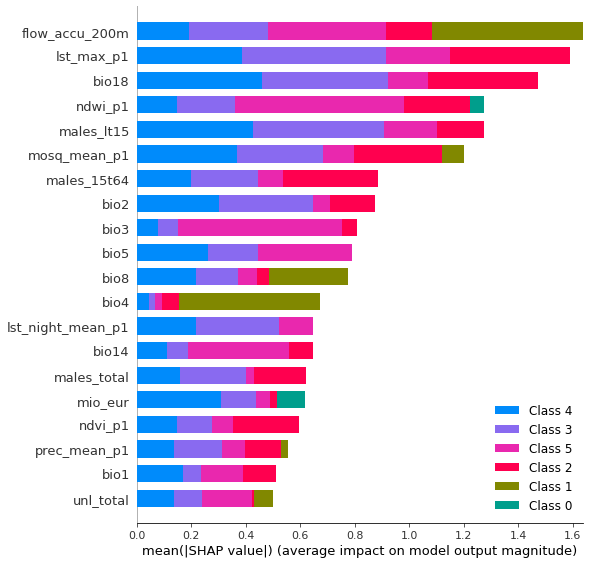

In [24]:
shap.summary_plot(shap_values = shap_values, features = feature_names)

In [29]:
shap_values_total = np.concatenate(shap_values, axis=0)

In [30]:
shap_values_total.shape

(2652, 61)

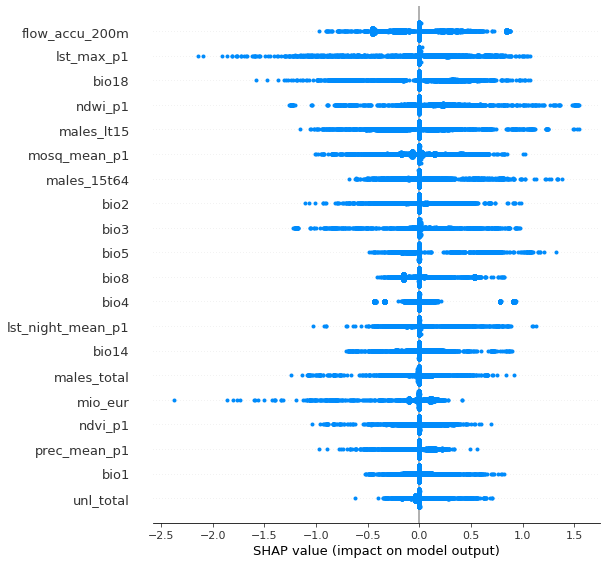

In [31]:
shap.summary_plot(shap_values = shap_values_total, features = feature_names)

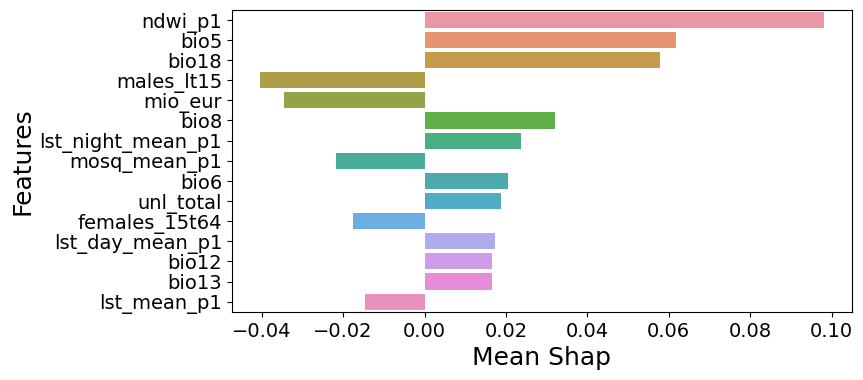

In [32]:
mean_shap = shap_values_total.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

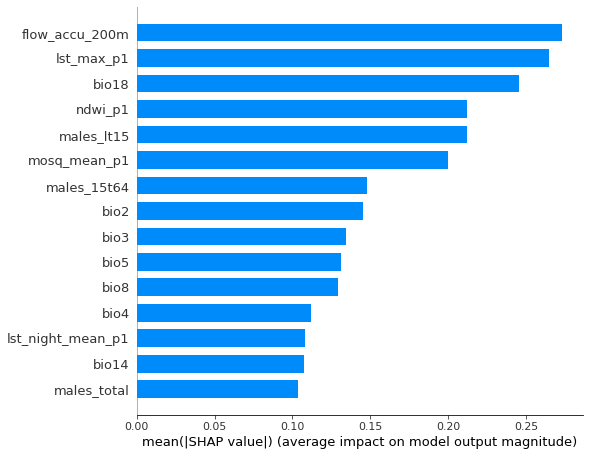

In [34]:
shap.summary_plot(shap_values_total, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
3,bioclimatic,0.287162
0,enviromental,0.118866
6,demographic,0.094847
1,climate,0.069004
7,economics,0.058326
5,geomorphological,0.049502
2,vectors,0.021846
4,landuse,0.004481


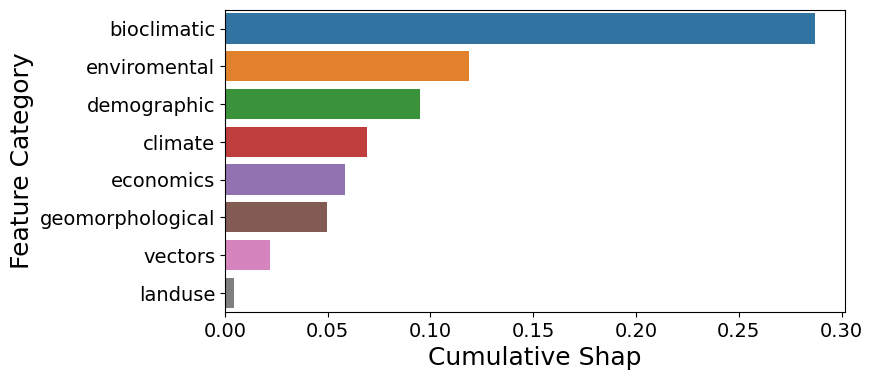

In [37]:
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_landuse = shaps.loc[shaps['features'].isin(landuse)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_economics = shaps.loc[shaps['features'].isin(economics)].drop(columns=['weights'])

categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.sum(),df_climate.weights_abs.sum(),df_vectors.weights_abs.sum(),
                            df_bioclimatic.weights_abs.sum(),df_landuse.weights_abs.sum(),df_geomorphological.weights_abs.sum(),
                            df_demographic.weights_abs.sum(), df_economics.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
0,enviromental,0.029717
7,economics,0.019442
3,bioclimatic,0.015114
6,demographic,0.011856
2,vectors,0.010923
1,climate,0.009858
5,geomorphological,0.003094
4,landuse,0.002240


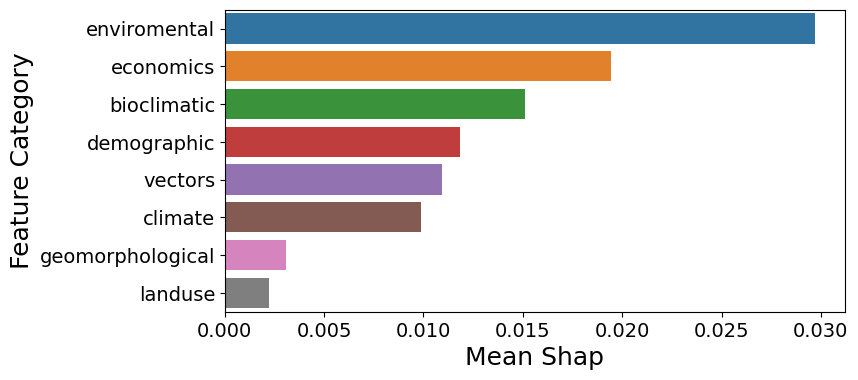

In [38]:
categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.mean(),df_climate.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_bioclimatic.weights_abs.mean(),df_landuse.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_demographic.weights_abs.mean(), df_economics.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))